# House Price Prediction — End-to-End ML Notebook

This notebook follows the Student Project Guide from data inspection through cleaning, EDA, model comparison, evaluation, and export. The target is the listing amount in rupees (`Amount(in rupees)`), not the `Price (in rupees)` price-per-square-foot field.

> **Reproducibility:** The raw CSV is intentionally excluded from Git. Download it from the Kaggle dataset linked in the project README and place it at `notebooks/data/house_prices.csv`.


## 2.1 Load & Inspect

In [1]:

from pathlib import Path
import re, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

DATA_CANDIDATES = [
    Path("data/house_prices.csv"),
    Path("notebooks/data/house_prices.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place house_prices.csv in notebooks/data/ or data/.")

df_raw = pd.read_csv(DATA_PATH)
print("Dataset shape:", df_raw.shape)
display(df_raw.head())
print("\nColumns:")
print(df_raw.columns.tolist())
print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))


Dataset shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



Columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']

Data types:


,dtype
Index,int64
Title,object
Description,object
Amount(in rupees),object
Price (in rupees),float64
location,object
Carpet Area,object
Status,object
Floor,object
Transaction,object


In [2]:

print("Rows:", len(df_raw))
print("Columns:", len(df_raw.columns))
numeric_columns = df_raw.select_dtypes(include=np.number).columns.tolist()
text_columns = df_raw.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric columns:", numeric_columns)
print("Text/categorical columns:", text_columns)
print("\nMissing-value percentage:")
display((df_raw.isna().mean().sort_values(ascending=False) * 100).round(2).to_frame("missing_pct").head(15))
print("\nSummary statistics:")
display(df_raw.describe(include="all").T.head(21))


Rows: 187531
Columns: 21
Numeric columns: ['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area']
Text/categorical columns: ['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area']

Missing-value percentage:


,missing_pct
Plot Area,100.00
Dimensions,100.00
Society,58.49
Super Area,57.42
Car Parking,55.11
overlooking,43.43
Carpet Area,43.02
facing,37.45
Ownership,34.94
Balcony,26.09



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Inspection notes.** The supplied CSV contains 187,531 rows and 21 columns. The numeric fields include `Index`, `Price (in rupees)`, `Dimensions`, and `Plot Area`; most property attributes are stored as text. The largest missingness is in `Plot Area`, `Dimensions`, `Society`, `Super Area`, `Car Parking`, and `overlooking`. We will verify and handle these fields from the actual file rather than relying only on the dataset description.

## 2.2 Exploratory Data Analysis (EDA)

In [3]:

def parse_amount(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace("₹", "").replace(",", "")
    if s in {"", "nan", "na", "n/a", "call for price", "contact for price"}:
        return np.nan
    try:
        if "lac" in s:
            return float(re.sub(r"[^0-9.]+", "", s.split("lac")[0])) * 1e5
        if "cr" in s:
            return float(re.sub(r"[^0-9.]+", "", s.split("cr")[0])) * 1e7
        return float(re.sub(r"[^0-9.]+", "", s))
    except (TypeError, ValueError):
        return np.nan

UNIT_TO_SQFT = {
    "sqft": 1.0, "sqm": 10.7639, "sqyrd": 9.0,
    "marla": 272.25, "acre": 43560.0, "kanal": 5445.0,
    "ground": 2400.0, "cent": 435.6, "hectare": 107639.104,
    "bigha": 27225.0, "biswa": 1350.0, "aankadam": 72.0,
}

def parse_area(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().replace(",", "")
    match = re.search(r"([0-9.]+)\s*([a-z]+)", s)
    if not match:
        return np.nan
    value, unit = float(match.group(1)), match.group(2)
    return value * UNIT_TO_SQFT.get(unit, np.nan)

def parse_floor(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "lower basement" in s:
        return -1.0
    if "upper basement" in s:
        return -2.0
    if "basement" in s:
        return -1.0
    if "ground" in s:
        return 0.0
    match = re.match(r"\s*(\d+)", s)
    return float(match.group(1)) if match else np.nan

def parse_numeric(x):
    if pd.isna(x):
        return np.nan
    match = re.search(r"\d+(?:\.\d+)?", str(x))
    return float(match.group()) if match else np.nan

df = df_raw.copy()
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)
# Preserve more usable listings: use Super Area as a fallback only when Carpet Area is missing.
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
df["floor_num"] = df["Floor"].apply(parse_floor)
df["bathroom"] = df["Bathroom"].apply(parse_numeric)
df["balcony"] = df["Balcony"].apply(parse_numeric)
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

print("Rows with usable parsed price:", int(df["price_clean"].notna().sum()))
print("Rows with usable area after fallback:", int(df["carpet_area_sqft"].notna().sum()))


Rows with usable parsed price: 177847
Rows with usable area after fallback: 186704


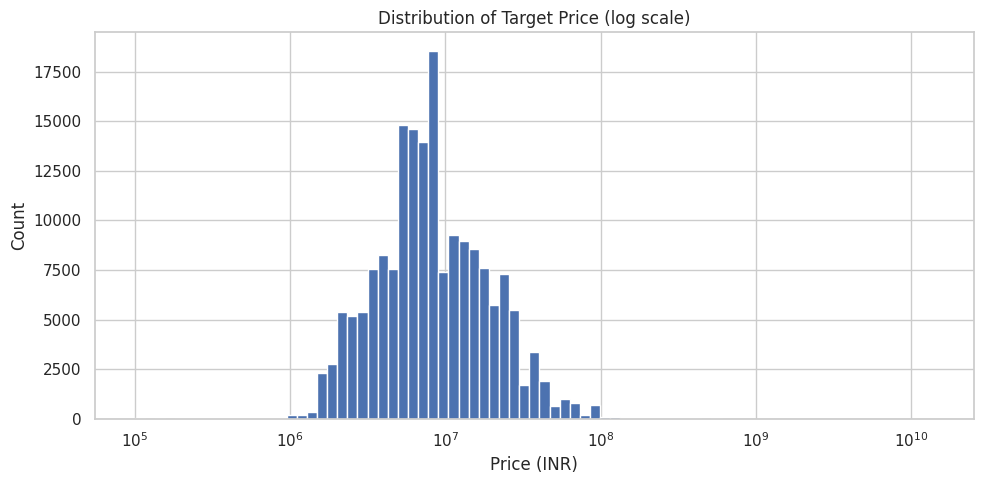

In [4]:

plt.figure(figsize=(10, 5))
plt.hist(df["price_clean"].dropna(), bins=np.logspace(np.log10(df["price_clean"].dropna().min()), np.log10(df["price_clean"].dropna().max()), 80))
plt.xscale("log")
plt.title("Distribution of Target Price (log scale)")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/eda_price_distribution.png", dpi=160)
plt.show()


**Plot 1 interpretation:** The target is strongly right-skewed, so a logarithmic x-axis makes the distribution easier to inspect and prevents the very largest listings from dominating the visual.

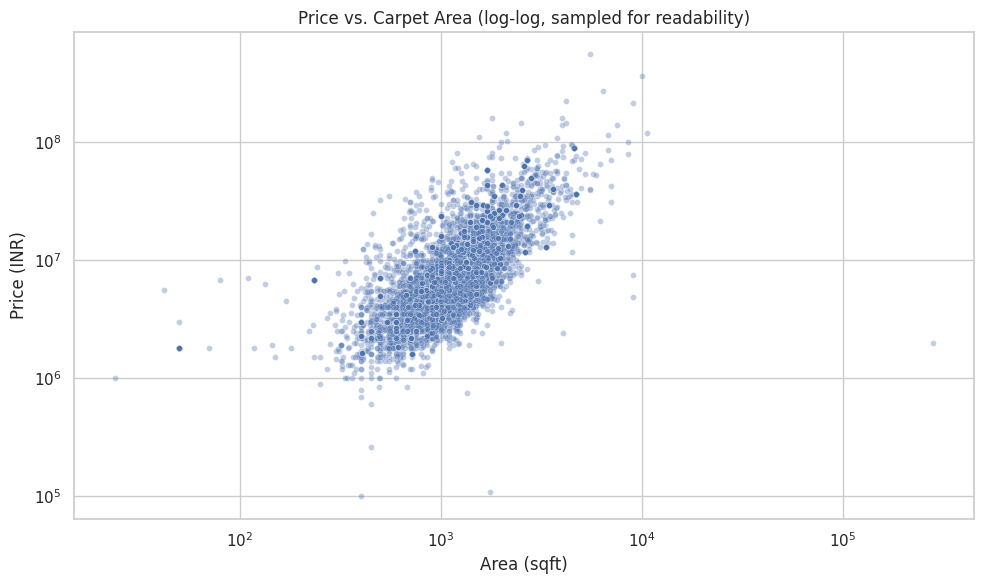

In [5]:

plt.figure(figsize=(10, 6))
plot_df = df.dropna(subset=["carpet_area_sqft", "price_clean"]).sample(
    n=min(12000, df.dropna(subset=["carpet_area_sqft", "price_clean"]).shape[0]),
    random_state=42
)
sns.scatterplot(data=plot_df, x="carpet_area_sqft", y="price_clean", alpha=0.35, s=18)
plt.yscale("log")
plt.xscale("log")
plt.title("Price vs. Carpet Area (log-log, sampled for readability)")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig("../reports/eda_price_vs_area.png", dpi=160)
plt.show()


**Plot 2 interpretation:** Larger properties generally command higher prices, but the relationship is dispersed because location and property attributes strongly affect price. A log-log view makes both small and large properties visible.

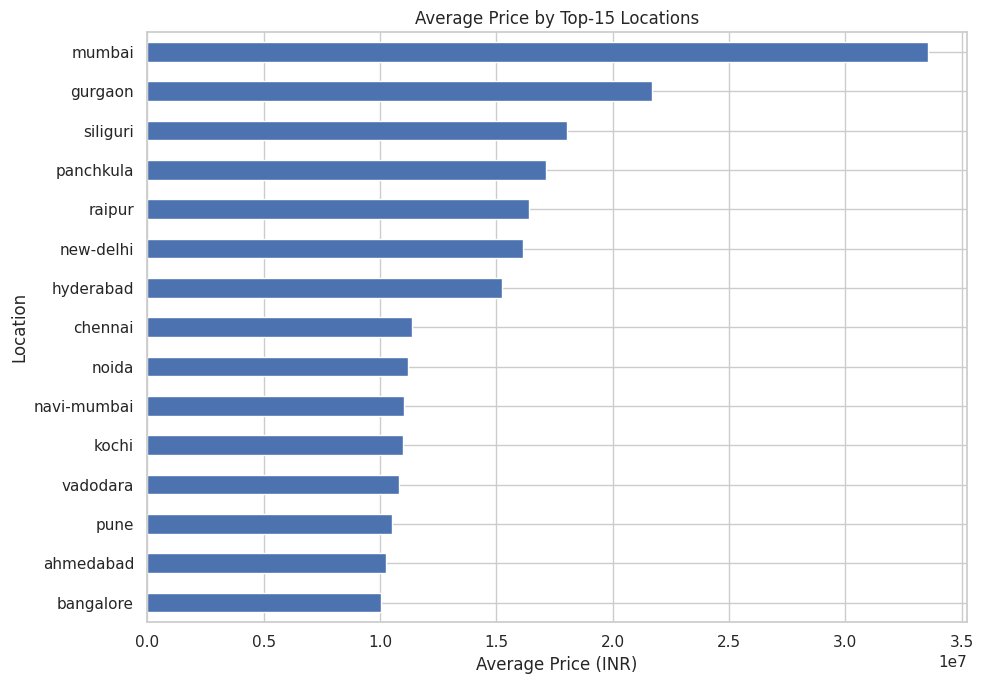

In [6]:

top15 = df.dropna(subset=["location", "price_clean"]).groupby("location")["price_clean"].mean().nlargest(15).sort_values()
plt.figure(figsize=(10, 7))
top15.plot(kind="barh")
plt.title("Average Price by Top-15 Locations")
plt.xlabel("Average Price (INR)")
plt.ylabel("Location")
plt.tight_layout()
plt.savefig("../reports/eda_top15_locations.png", dpi=160)
plt.show()


**Plot 3 interpretation:** Average prices vary substantially by location. This supports keeping location as a categorical predictor while reducing its cardinality to the 50 most frequent locations.

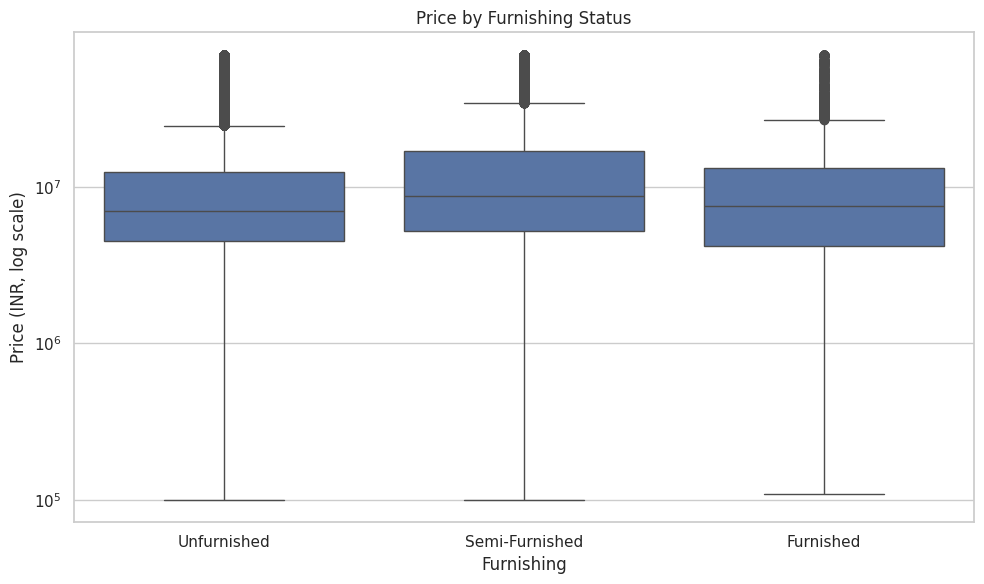

In [7]:

box_df = df.dropna(subset=["Furnishing", "price_clean"]).copy()
box_df["price_clean"] = box_df["price_clean"].clip(
    upper=box_df["price_clean"].quantile(0.99)
)
plt.figure(figsize=(10, 6))
sns.boxplot(data=box_df, x="Furnishing", y="price_clean")
plt.yscale("log")
plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (INR, log scale)")
plt.tight_layout()
plt.savefig("../reports/eda_furnishing_boxplot.png", dpi=160)
plt.show()


**Plot 4 interpretation:** Furnishing status is associated with different price distributions, although there is considerable overlap. This makes furnishing a useful categorical feature rather than a standalone pricing rule.

## 2.3 Cleaning & Feature Engineering

In [8]:

# Remove rows without a usable target or usable area.
df = df[(df["price_clean"] > 0) & (df["carpet_area_sqft"] > 0)].copy()

# Remove extreme price-per-square-foot outliers using the requested 1st/99th percentile rule.
ppsf_low, ppsf_high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[df["price_per_sqft"].between(ppsf_low, ppsf_high)].copy()
print(f"Outlier bounds: {ppsf_low:,.2f} to {ppsf_high:,.2f} INR/sqft")
print(f"Rows removed by target/area/outlier cleaning: {before - len(df):,}")
print(f"Rows remaining: {len(df):,}")

# High-cardinality handling: keep the 50 most frequent locations and group the rest.
top_locations = df["location"].value_counts().head(50).index.tolist()
df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations), "Other"
)

# Deliberately dropped from modeling:
# Index, Title, Description, Price (in rupees), Status, Society, Super Area,
# Dimensions, Plot Area, Car Parking, overlooking.
# Reasons: identifiers/free text, target leakage (price/sqft), redundant/high-cardinality
# or nearly-empty fields, and fields not required by the guide's serving schema.
print("Grouped location levels:", df["location_grouped"].nunique())
print("Selected features:")
print(["carpet_area_sqft", "floor_num", "bathroom", "balcony",
       "location_grouped", "Furnishing", "Transaction", "Ownership", "facing"])


Outlier bounds: 2,260.72 to 33,882.35 INR/sqft
Rows removed by target/area/outlier cleaning: 3,469
Rows remaining: 174,288
Grouped location levels: 51
Selected features:
['carpet_area_sqft', 'floor_num', 'bathroom', 'balcony', 'location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']


### Cleaning decisions
- **Price:** converted `Lac` to ₹100,000 and `Cr` to ₹10,000,000; unusable prices were removed.
- **Area:** converted common units to sqft. `Super Area` is used only as a fallback when `Carpet Area` is missing.
- **Floor:** extracted the first numeric floor; `Ground` → 0 and basement levels are negative.
- **Bathroom/Balcony:** extracted numeric values and left missing values for pipeline median imputation.
- **Location:** retained the top 50 most frequent locations and mapped all other locations to `Other`.
- **Dropped fields:** identifiers/free text, target-leakage `Price (in rupees)`, very sparse/redundant fields, and fields not required by the serving schema.
- **Outliers:** removed listings outside the 1st–99th percentile of price-per-sqft after parsing, as requested by the guide.

## 2.4 Build a Pipeline & Train

In [9]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

models = {
    "LinearRegression": Pipeline([
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]),
    "RandomForestRegressor": Pipeline([
        ("prep", preprocessor),
        ("reg", RandomForestRegressor(
            n_estimators=40,
            max_depth=18,
            min_samples_leaf=5,
            max_features=0.8,
            max_samples=0.5,
            random_state=42,
            n_jobs=2
        ))
    ])
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred),
    }

metrics_df = pd.DataFrame(results).T.sort_values("RMSE")
display(metrics_df.style.format("{:,.4f}"))


,MAE,RMSE,R2
RandomForestRegressor,"1,165,597.9216","3,649,252.1434",0.9100
LinearRegression,"4,148,746.6217","7,122,175.5234",0.6572


## 2.5 Evaluate

In [10]:

chosen_name = metrics_df.index[0]
chosen_model = models[chosen_name]
chosen_pred = predictions[chosen_name]

print("Chosen model:", chosen_name)
print(f"MAE : {metrics_df.loc[chosen_name, 'MAE']:,.2f} INR")
print(f"RMSE: {metrics_df.loc[chosen_name, 'RMSE']:,.2f} INR")
print(f"R²  : {metrics_df.loc[chosen_name, 'R2']:.4f}")


Chosen model: RandomForestRegressor
MAE : 1,165,597.92 INR
RMSE: 3,649,252.14 INR
R²  : 0.9100


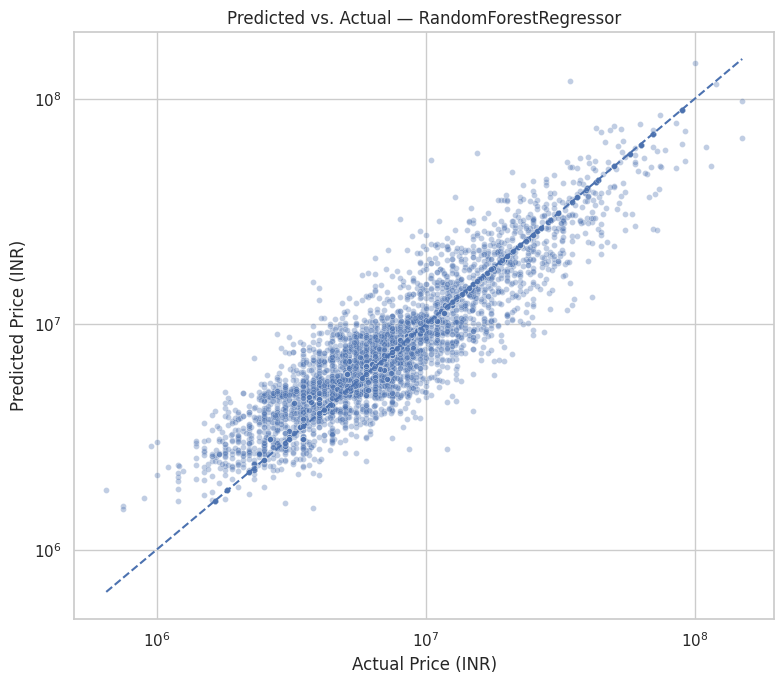

In [11]:

plt.figure(figsize=(8, 7))
scatter_sample = pd.DataFrame({"actual": y_test.values, "predicted": chosen_pred}).sample(
    n=min(10000, len(y_test)), random_state=42
)
sns.scatterplot(data=scatter_sample, x="actual", y="predicted", alpha=0.35, s=18)
lims = [scatter_sample[["actual", "predicted"]].min().min(),
        scatter_sample[["actual", "predicted"]].max().max()]
plt.plot(lims, lims, linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Predicted vs. Actual — {chosen_name}")
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.tight_layout()
plt.savefig("../reports/predicted_vs_actual.png", dpi=160)
plt.show()


**Evaluation interpretation:** The comparison is based only on the held-out test set. The winner is selected by the lowest RMSE while also considering MAE and R². The predicted-vs-actual plot checks whether predictions broadly follow the ideal diagonal relationship.

### Bonus: 5-fold cross-validation

In [12]:

from sklearn.model_selection import cross_val_score

# A fixed 20,000-row sample keeps the bonus reproducible and practical on student laptops.
cv_n = min(20000, len(X_train))
X_cv = X_train.sample(cv_n, random_state=42)
y_cv = y_train.loc[X_cv.index]
cv_scores = cross_val_score(
    chosen_model, X_cv, y_cv, cv=5, scoring="r2", n_jobs=1
)
print("5-fold R² scores:", np.round(cv_scores, 4))
print("Mean 5-fold R²:", round(cv_scores.mean(), 4))
print("Std 5-fold R² :", round(cv_scores.std(), 4))


5-fold R² scores: [0.8339 0.8651 0.9121 0.846  0.8584]
Mean 5-fold R²: 0.8631
Std 5-fold R² : 0.0267


In [13]:

# Persist the exact trained pipeline used by the backend.
Path("../models").mkdir(exist_ok=True)
joblib.dump(chosen_model, "../models/house_price.pkl")

with open("../models/locations.json", "w", encoding="utf-8") as f:
    json.dump(sorted(top_locations), f, ensure_ascii=False, indent=2)

metadata = {
    "model": chosen_name,
    "sklearn_version": __import__("sklearn").__version__,
    "test_size": 0.20,
    "random_state": 42,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "metrics": {k: float(v) for k, v in results[chosen_name].items()},
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "clean_rows": int(len(df)),
}
with open("../models/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved models/house_price.pkl, locations.json, and model_metadata.json")


Saved models/house_price.pkl, locations.json, and model_metadata.json


In [14]:

# Sanity check: reload and predict one test sample.
loaded = joblib.load("../models/house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", float(loaded.predict(sample)[0]))
print("Actual price:", float(y_test.iloc[0]))


Reloaded prediction: 8502652.686908731
Actual price: 8500000.0


## Conclusion

In [15]:

winner = metrics_df.index[0]
row = metrics_df.loc[winner]
print(
    f"{winner} is the selected model because it achieved the lowest test RMSE "
    f"({row['RMSE']:,.0f} INR), with MAE {row['MAE']:,.0f} INR and R² {row['R2']:.4f}. "
    "The full preprocessing and model are bundled in one scikit-learn Pipeline, "
    "so the FastAPI backend can accept raw feature values without reproducing "
    "imputation or one-hot encoding logic."
)


RandomForestRegressor is the selected model because it achieved the lowest test RMSE (3,649,252 INR), with MAE 1,165,598 INR and R² 0.9100. The full preprocessing and model are bundled in one scikit-learn Pipeline, so the FastAPI backend can accept raw feature values without reproducing imputation or one-hot encoding logic.
